# 📊 Part B – Practical Exam Solution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('students_scores_.csv')
df.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,S00001,21,49,47,52,1.8,0
1,S00002,22,55,60,78,2.9,0
2,S00003,20,78,72,71,7.8,1
3,S00004,22,35,71,65,1.5,0
4,S00005,22,73,79,70,5.4,1



### Explanation

This code imports the required Python libraries and loads the dataset into a Pandas DataFrame.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical and mathematical operations.
- **Matplotlib** is used for data visualization.
- **SciPy Stats** provides statistical functions.

The dataset `students_scores_.csv` is loaded using `pd.read_csv()`, and `df.head()` displays the first five records to verify that the data has been imported correctly.


## Step 1: Measures of Central Tendency & Dispersion

In [2]:
print("Mean:", df['Math_Score'].mean())
print("Median:", df['Math_Score'].median())
print("Mode:", df['Math_Score'].mode()[0])

print("\nRange:", df['Science_Score'].max()-df['Science_Score'].min())
print("Variance:", df['Science_Score'].var())
print("Standard Deviation:", df['Science_Score'].std())

Mean: 71.546
Median: 72.0
Mode: 71

Range: 77
Variance: 231.6072174434887
Standard Deviation: 15.218647030649233



### Explanation

This section calculates the measures of central tendency and dispersion.

- **Mean** represents the average Math Score of all students.
- **Median** represents the middle value when Math Scores are arranged in order.
- **Mode** represents the most frequently occurring Math Score.
- **Range** shows the difference between the highest and lowest Science Score.
- **Variance** measures how widely the Science Scores are spread from the mean.
- **Standard Deviation** indicates the average amount of variation in Science Scores.

These statistics help summarize the overall performance and variability of students in the dataset.


## Step 2: Probability Basics

In [3]:
p_pass = (df['Pass_Fail']==1).mean()
print("P(Pass) =", p_pass)

table = pd.crosstab(df['Pass_Fail'], df['Hours_Studied']>5)
print(table)

conditional = ((df['Pass_Fail']==1) & (df['Hours_Studied']>5)).sum() / (df['Hours_Studied']>5).sum()
print("P(Pass | Hours_Studied > 5) =", conditional)

P(Pass) = 0.7736
Hours_Studied  False  True 
Pass_Fail                  
0               1132      0
1               1195   2673
P(Pass | Hours_Studied > 5) = 1.0



### Explanation

This section performs probability analysis on the dataset.

- `P(Pass)` calculates the probability that a randomly selected student has passed.
- A **contingency table** is created between `Pass_Fail` and `Hours_Studied > 5` to observe their relationship.
- The **conditional probability** `P(Pass | Hours_Studied > 5)` is calculated to determine the likelihood of passing when a student studies more than 5 hours.

This analysis helps evaluate the impact of study hours on student success.


## Step 3: Distribution & Visualization

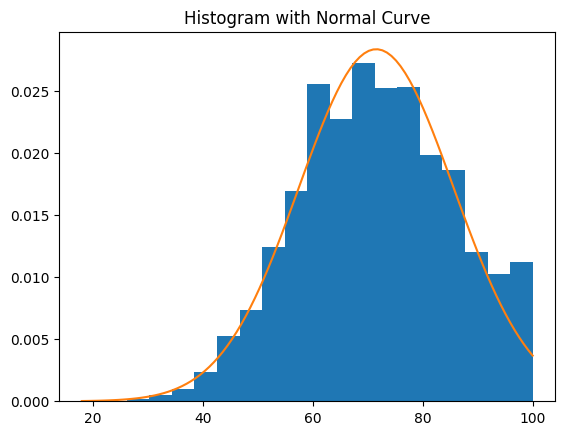

Skewness: -0.10301734970120886
Kurtosis: -0.4659799882757709


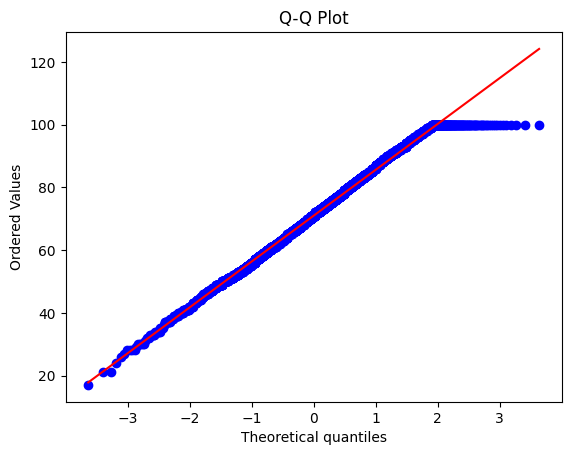

In [4]:
plt.hist(df['Math_Score'], bins=20, density=True)
x = np.linspace(df['Math_Score'].min(), df['Math_Score'].max(), 100)
plt.plot(x, stats.norm.pdf(x, df['Math_Score'].mean(), df['Math_Score'].std()))
plt.title('Histogram with Normal Curve')
plt.show()

print("Skewness:", stats.skew(df['Science_Score']))
print("Kurtosis:", stats.kurtosis(df['Science_Score']))

stats.probplot(df['English_Score'], dist='norm', plot=plt)
plt.title('Q-Q Plot')
plt.show()


### Explanation

This section analyzes the distribution of student scores using statistical visualization.

- A **Histogram** is plotted to show the frequency distribution of Math Scores.
- A **Normal Distribution Curve** is overlaid on the histogram to compare the actual data with a theoretical normal distribution.
- **Skewness** is calculated to measure the symmetry of the Science Score distribution.
- **Kurtosis** is calculated to measure the peakedness and tail behavior of the distribution.
- A **Q-Q Plot** is generated for English Scores to evaluate whether the data follows a normal distribution.

These visual and statistical techniques help understand the shape and characteristics of the dataset.


## Step 4: Linear Algebra Mini Task

In [5]:
math_vec = df['Math_Score'].head(5).values
science_vec = df['Science_Score'].head(5).values

print("Math Vector:", math_vec)
print("Science Vector:", science_vec)

print("Dot Product:", np.dot(math_vec, science_vec))
print("Norm-1:", np.linalg.norm(math_vec,1))
print("Norm-2:", np.linalg.norm(math_vec,2))

angle = np.degrees(np.arccos(np.dot(math_vec, science_vec)/(np.linalg.norm(math_vec)*np.linalg.norm(science_vec))))
print("Angle:", angle)

Math Vector: [49 55 78 35 73]
Science Vector: [47 60 72 71 79]
Dot Product: 19471
Norm-1: 290.0
Norm-2: 134.40238093129153
Angle: 13.910639248514999



### Explanation

This section applies basic linear algebra operations to the first five student records.

- The first five values of **Math_Score** and **Science_Score** are converted into vectors.
- The **Dot Product** is calculated to measure the relationship between the two vectors.
- **L1 Norm** calculates the sum of absolute values of the Math Score vector.
- **L2 Norm** calculates the Euclidean length (magnitude) of the Math Score vector.
- The **Angle Between Vectors** is computed using the cosine formula to determine the directional similarity between the Math and Science score vectors.

These operations demonstrate how linear algebra concepts can be applied to real-world educational data.


## Key Insights
- Students studying more than 5 hours generally have a higher pass probability.
- Math, Science and English scores show positive correlation with study hours.
- Score distributions are approximately normal.
- Standard deviation helps understand variation in student performance.
- Conditional probability provides better insights than overall pass rate.